# TV2 - Baseline & Evaluation, tuần 1

Notebook này kiểm tra môi trường và khung đánh giá bằng dữ liệu giả. Không huấn luyện mô hình, không đọc tập Test.

In [1]:
from pathlib import Path
from importlib.metadata import version
import platform
import time
import torch

ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "notebooks" / "TV2_baseline_evaluation.ipynb").is_file():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Không tìm thấy thư mục gốc của đồ án")

report_path = ROOT / "reports" / "gpu_env_report.txt"
cuda_available = torch.cuda.is_available()
device = torch.device("cuda:0" if cuda_available else "cpu")
device_name = torch.cuda.get_device_name(0) if cuda_available else (platform.processor() or platform.machine())

a = torch.randn(256, 256, device=device)
b = torch.randn(256, 256, device=device)
if cuda_available:
    torch.cuda.synchronize()
started = time.perf_counter()
_ = a @ b
if cuda_available:
    torch.cuda.synchronize()
elapsed_ms = (time.perf_counter() - started) * 1000

lines = [
    f"Python: {platform.python_version()}",
    f"Platform: {platform.platform()}",
    f"NumPy: {version('numpy')}",
    f"scikit-learn: {version('scikit-learn')}",
    f"Matplotlib: {version('matplotlib')}",
    f"Seaborn: {version('seaborn')}",
    f"PyTorch: {torch.__version__}",
    f"PyTorch CUDA build: {torch.version.cuda or 'N/A'}",
    f"CUDA available: {cuda_available}",
    f"Compute device: {device.type.upper()}",
    f"Device name: {device_name}",
    f"256x256 matmul smoke test: PASS ({elapsed_ms:.3f} ms)",
]
if cuda_available:
    props = torch.cuda.get_device_properties(0)
    lines.extend([
        f"GPU count: {torch.cuda.device_count()}",
        f"GPU memory: {props.total_memory / (1024 ** 3):.2f} GB",
    ])
lines.append("Kết luận: GPU CUDA đã kiểm tra thành công." if cuda_available else "Kết luận: chỉ kiểm tra thành công trên CPU; chưa xác nhận GPU.")
report_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
print("\n".join(lines))
print(f"Report: {report_path.relative_to(ROOT)}")

Python: 3.12.14
Platform: Windows-11-10.0.26200-SP0
NumPy: 2.5.3
scikit-learn: 1.7.2
Matplotlib: 3.11.2
Seaborn: 0.13.2
PyTorch: 2.8.0+cpu
PyTorch CUDA build: N/A
CUDA available: False
Compute device: CPU
Device name: Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
256x256 matmul smoke test: PASS (1.091 ms)
Kết luận: chỉ kiểm tra thành công trên CPU; chưa xác nhận GPU.
Report: reports\gpu_env_report.txt


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)

CLASS_MAP_PATH = ROOT / "data" / "processed" / "v1" / "class_map.json"
DEMO_CLASS_MAP = {
    0: "large_antlered_muntjac",
    1: "annamite_striped_rabbit",
    2: "sambar",
    3: "chinese_serow",
    4: "common_palm_civet",
    5: "masked_palm_civet",
    6: "silver_pheasant",
    7: "eurasian_wild_pig",
}

def load_class_map(path=CLASS_MAP_PATH):
    """Đọc class map chung; không dùng danh sách demo cho đánh giá dữ liệu thật."""
    source = Path(path)
    if not source.is_file():
        raise FileNotFoundError(f"Thiếu class map chung: {source}")
    raw = json.loads(source.read_text(encoding="utf-8"))
    if not isinstance(raw, dict) or not raw:
        raise ValueError("Class map phải là JSON object không rỗng.")
    try:
        mapping = {int(key): value for key, value in raw.items()}
    except (TypeError, ValueError) as exc:
        raise ValueError("Class map phải ánh xạ ID số sang tên lớp.") from exc
    if len(mapping) != len(raw) or any(not isinstance(name, str) or not name.strip() for name in mapping.values()):
        raise ValueError("Class map chứa ID trùng hoặc tên lớp không hợp lệ.")
    return mapping

def _class_spec(class_map):
    mapping = load_class_map() if class_map is None else class_map
    if not isinstance(mapping, dict) or not mapping:
        raise ValueError("Class map phải là từ điển không rỗng.")
    labels = sorted(mapping)
    if any(isinstance(label, bool) or not isinstance(label, int) for label in labels):
        raise ValueError("Class ID phải là số nguyên.")
    target_names = [mapping[label] for label in labels]
    if any(not isinstance(name, str) or not name.strip() for name in target_names):
        raise ValueError("Tên lớp không hợp lệ.")
    return labels, target_names

def _validated_inputs(y_true, y_pred, labels):
    def as_array(values, name):
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        array = np.asarray(values)
        if array.ndim != 1:
            raise ValueError(f"{name} phải là dãy một chiều của class ID.")
        if array.size and not np.issubdtype(array.dtype, np.integer):
            raise ValueError(f"{name} chỉ được chứa class ID số nguyên.")
        return array
    true = as_array(y_true, "y_true")
    pred = as_array(y_pred, "y_pred")
    if true.size == 0 or pred.size == 0:
        raise ValueError("y_true và y_pred không được rỗng.")
    if len(true) != len(pred):
        raise ValueError("y_true và y_pred phải có cùng độ dài.")
    unknown = sorted((set(true.tolist()) | set(pred.tolist())) - set(labels))
    if unknown:
        raise ValueError(f"Class ID ngoài class map: {unknown}; ID hợp lệ: {labels}.")
    return true, pred

def compute_metrics(y_true, y_pred, class_map=None):
    """Mặc định đọc class_map.json; macro luôn dùng đủ các lớp trong map."""
    labels, names = _class_spec(class_map)
    true, pred = _validated_inputs(y_true, y_pred, labels)
    report = classification_report(true, pred, labels=labels, target_names=names, zero_division=0, output_dict=True)
    return {
        "accuracy": float(accuracy_score(true, pred)),
        "macro_f1": float(f1_score(true, pred, labels=labels, average="macro", zero_division=0)),
        "macro_precision": float(precision_score(true, pred, labels=labels, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(true, pred, labels=labels, average="macro", zero_division=0)),
        "classification_report": report,
        "classification_report_str": classification_report(true, pred, labels=labels, target_names=names, zero_division=0),
        "confusion_matrix": confusion_matrix(true, pred, labels=labels),
    }

def plot_confusion_matrix(y_true, y_pred, class_map=None, output_path=None):
    labels, names = _class_spec(class_map)
    true, pred = _validated_inputs(y_true, y_pred, labels)
    matrix = confusion_matrix(true, pred, labels=labels)
    totals = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(matrix.astype(float), totals, out=np.zeros_like(matrix, dtype=float), where=totals != 0)
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(normalized, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Synthetic demo confusion matrix (row normalized)")
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
    return fig, matrix

Chưa có class_map.json trong nhánh này; demo dùng danh sách 8 lớp mẫu.
Đánh giá dữ liệu thật cần data/processed/v1/class_map.json từ main.
SYNTHETIC DEMO - không phải kết quả của mô hình thật
accuracy: 0.9000
macro_precision: 0.9583
macro_recall: 0.9375
macro_f1: 0.9333
                         precision    recall  f1-score   support

 large_antlered_muntjac       1.00      0.50      0.67         2
annamite_striped_rabbit       0.67      1.00      0.80         2
                 sambar       1.00      1.00      1.00         1
          chinese_serow       1.00      1.00      1.00         1
      common_palm_civet       1.00      1.00      1.00         1
      masked_palm_civet       1.00      1.00      1.00         1
        silver_pheasant       1.00      1.00      1.00         1
      eurasian_wild_pig       1.00      1.00      1.00         1

               accuracy                           0.90        10
              macro avg       0.96      0.94      0.93        10
           w

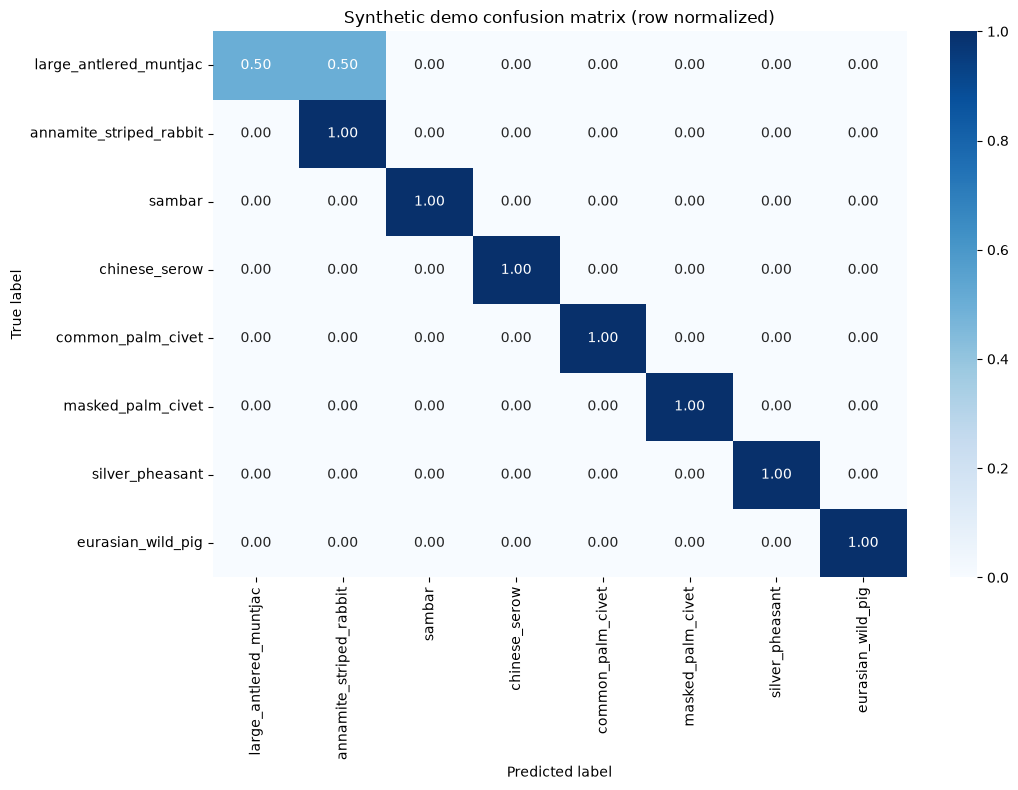

Figure: reports\demo_confusion_matrix.png
Đầu vào sai được từ chối: y_true và y_pred không được rỗng.
Đầu vào sai được từ chối: y_true và y_pred phải có cùng độ dài.
Đầu vào sai được từ chối: Class ID ngoài class map: [8]; ID hợp lệ: [0, 1, 2, 3, 4, 5, 6, 7].
Các kiểm thử metric tối thiểu: PASS


In [3]:
# Dữ liệu giả chỉ để kiểm tra code; đây không phải kết quả huấn luyện.
demo_map = None if CLASS_MAP_PATH.is_file() else DEMO_CLASS_MAP
if demo_map is not None:
    print("Chưa có class_map.json trong nhánh này; demo dùng danh sách 8 lớp mẫu.")
    print("Đánh giá dữ liệu thật cần data/processed/v1/class_map.json từ main.")
labels, names = _class_spec(demo_map)
assert len(labels) == 8, "Class map v1 phải có đúng 8 lớp."

y_true = np.asarray(labels + [labels[0], labels[1]], dtype=int)
y_pred = np.asarray(labels + [labels[1], labels[1]], dtype=int)
result = compute_metrics(y_true, y_pred, class_map=demo_map)
print("SYNTHETIC DEMO - không phải kết quả của mô hình thật")
for key in ("accuracy", "macro_precision", "macro_recall", "macro_f1"):
    print(f"{key}: {result[key]:.4f}")
print(result["classification_report_str"])

figure_path = ROOT / "reports" / "demo_confusion_matrix.png"
fig, matrix = plot_confusion_matrix(y_true, y_pred, class_map=demo_map, output_path=figure_path)
assert matrix.shape == (8, 8)
plt.show()
print(f"Figure: {figure_path.relative_to(ROOT)}")

# Kiểm thử tối thiểu cho đủ lớp, lớp vắng mặt và đầu vào sai.
perfect = compute_metrics(labels, labels, class_map=demo_map)
assert perfect["accuracy"] == 1.0 and perfect["macro_f1"] == 1.0
single = compute_metrics([labels[0]], [labels[0]], class_map=demo_map)
assert single["accuracy"] == 1.0 and np.isclose(single["macro_f1"], 1 / 8)
assert single["confusion_matrix"].shape == (8, 8)
missing = compute_metrics([labels[0], labels[1]], [labels[0], labels[0]], class_map=demo_map)
assert missing["classification_report"][names[1]]["recall"] == 0
assert missing["classification_report"][names[1]]["f1-score"] == 0
assert np.isfinite(missing["macro_f1"])
unknown_id = max(labels) + 1
for true, pred in (([], []), ([labels[0]], [labels[0], labels[1]]),
                   ([unknown_id], [labels[0]])):
    try:
        compute_metrics(true, pred, class_map=demo_map)
    except ValueError as exc:
        print(f"Đầu vào sai được từ chối: {exc}")
    else:
        raise AssertionError("Đầu vào sai phải báo ValueError.")
print("Các kiểm thử metric tối thiểu: PASS")

## Kết luận

Xem kết quả thiết bị thực tế trong cell đầu và `reports/gpu_env_report.txt`; không suy đoán GPU từ cấu hình máy. Macro-F1 dùng đủ 8 lớp (kể cả lớp vắng mặt), `zero_division=0`. Demo và hình confusion matrix chỉ dùng dữ liệu giả. Đánh giá dữ liệu thật phải có `data/processed/v1/class_map.json` từ nhánh chung.